In [1]:
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

# number of fields per cell permutation test

In [64]:

df = {'cre': [], 'mouse': [], 'day': [], 'nov': [], 'n_fields': []}
for key, mice in zip(('ctrl', 'ko'),(ctrl_mice, ko_mice)):
    for mouse in mice:
        for d in range(6):
            sess = u.load_single_day(mouse,d)
            for nov in ('nov', 'fam'):
                sig_bins = sess.field_perm_masks['sig_bins'][nov]
                # print(sig_bins)
                _sig_bins = np.zeros((sig_bins.shape[0]+1, sig_bins.shape[1]))==1

                _sig_bins[1:,:] = sig_bins

                left_edges = 1*(_sig_bins[1:,:]>_sig_bins[:-1,:])
                n_fields = left_edges.sum(axis=0)
                n_fields = n_fields[n_fields>0]
                
                
                for n in n_fields:
                    df['cre'].append(key)
                    df['mouse'].append(mouse)
                    df['day'].append(mouse)
                    df['nov'].append(nov)
                    df['n_fields'].append(n)
                        
df = pd.DataFrame.from_dict(df)

{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 2}
{'date': '02_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 3}
{'date': '03_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 4}
{'date': '04_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 2}
({'date': '02_12_2020', 'scene': 'YMaze_LNovel', 

KeyboardInterrupt: 

(0.0, 1.1)

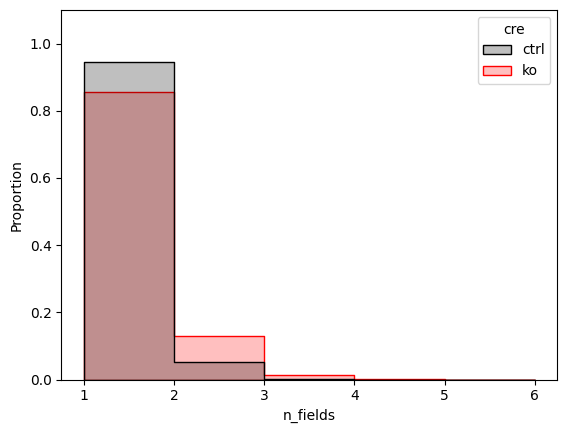

In [ ]:
fig,ax = plt.subplots()
sns.histplot(data=df, x='n_fields', hue='cre', cumulative=False, hue_order=('ctrl', 'ko'), palette=['black', 'red'],
            binwidth=1, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
ax.set_ylim([0,1.1])


In [ ]:
rank_sum_shuffle = []
rng = np.random.default_rng()
all_mice = ctrl_mice+ko_mice


for i, p in enumerate(itertools.combinations(ctrl_mice+ko_mice, len(ctrl_mice))):
    df_shuff = df.copy()
    df_shuff['cre']='ko'
    regexp = '|'.join(p)
    mask = df_shuff['mouse'].str.contains(regexp)
    df_shuff.loc[mask,'cre']='ctrl'

    stat, p = sp.stats.ranksums(df_shuff.loc[df_shuff['cre']=='ctrl','n_fields'],df_shuff.loc[df_shuff['cre']=='ko','n_fields'])
    rank_sum_shuffle.append(stat)
    if i%1000==0:
        print(i)

    

    

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000


In [ ]:
true_rank_sum,p = sp.stats.ranksums(df.loc[df['cre']=='ctrl','n_fields'],df.loc[df['cre']=='ko','n_fields'])

In [ ]:
p = (rank_sum_shuffle<true_rank_sum).sum().astype(float)/len(rank_sum_shuffle)
print(f'p-value = {p}')

p-value = 8.741258741258741e-05


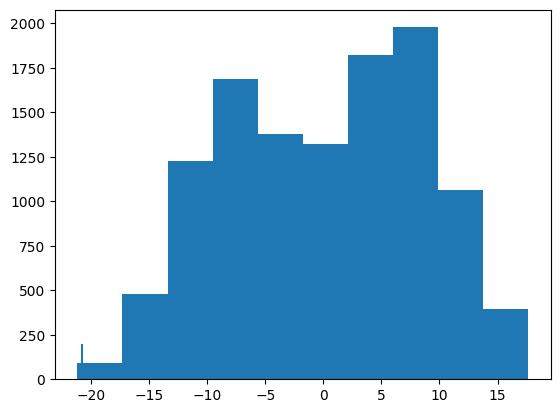

In [ ]:
fig, ax = plt.subplots()
ax.hist(rank_sum_shuffle)
ax.vlines(true_rank_sum,0,200)

In [ ]:
import pickle
with open('/home/mplitt/shuffle_pkls/place_field_ranksum_shuffle.pkl', 'wb') as f:
    pickle.dump({'rank_sums_shuffle': rank_sum_shuffle, 'true_rank_sum': true_rank_sum},f)

# field width 

In [2]:
df = {'cre': [], 'mouse': [], 'day': [], 'nov': [], 'width': [], 'speed': []}
for key, mice in zip(('ctrl', 'ko'),(ctrl_mice, ko_mice)):
    for mouse in mice:
        for d in range(6):
            sess = u.load_single_day(mouse,d)
            for nov in ('nov', 'fam'):
                if nov == 'fam':
                    trial_mask = sess.trial_info['LR']!=sess.novel_arm
                else:
                    trial_mask = sess.trial_info['LR']==sess.novel_arm

                sig_bins= sess.field_perm_masks['sig_bins'][nov]
                avg_speed = np.nanmean(sess.trial_matrices['speed'][trial_mask,:],axis=0)
                # print(avg_speed.shape)

                left_edges = np.argwhere(sig_bins[1:,:]>sig_bins[:-1,:]) # will exclude beginning of track
                for ledge in left_edges:
                    # print(ledge)
                    if ledge[0]<29:
                        rem_trial = sig_bins[ledge[0]:,ledge[1]]
                        falling_edges = rem_trial[1:]<rem_trial[:-1]
                        if falling_edges.sum()>0: # excludes end of track
                            redge = np.argwhere(falling_edges)[0][0]
                            df['cre'].append(key)
                            df['mouse'].append(mouse)
                            df['day'].append(d)
                            df['nov'].append(nov)
                            df['width'].append(10*redge)

                            df['speed'].append(avg_speed[ledge[0]:ledge[0]+redge+1][0])
                            # print(avg_speed[ledge[0]:ledge[0]+redge+1])
df = pd.DataFrame.from_dict(df)


{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 2}
{'date': '02_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 3}
{'date': '03_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 4}
{'date': '04_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 2}
({'date': '02_12_2020', 'scene': 'YMaze_LNovel', 

/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /media/mplitt/Backup Plus3/2P_Data/4467333.1/05_12_2020/YMaze_LNovel/YMaze_LNovel_001_002.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /media/mplitt/Backup Plus3/2P_Data/4467333.1/05_12_2020/YMaze_LNovel/YMaze_LNovel_001_002.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '16_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 2}
{'date': '17_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
{'date': '18_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 1, 'novel_arm': 1, 'ravel_ind': 4}
{'date': '19_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '16_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 2}
{'date': '17_10_2021', 'scene': 'YMaze_LNovel', 'ses

/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.1/28_09_2020/YMaze_LNovel/YMaze_LNovel_006_014.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.1/28_09_2020/YMaze_LNovel/YMaze_LNovel_006_014.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 2}


...

{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.3/02_10_2020/YMaze_LNovel/YMaze_LNovel_001_003.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.3/02_10_2020/YMaze_LNovel/YMaze_LNovel_001_003.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 6, 'novel_arm': -1, 'ravel_ind': 5}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.3/03_10_2020/YMaze_LNovel/YMaze_LNovel_001_006.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.3/03_10_2020/YMaze_LNovel/YMaze_LNovel_001_006.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 2}
{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 4}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': -1, 'ravel_ind': 2}
{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'ses

In [3]:
df['width'].unique()

array([ 60,  10,  50,  30,  20,  40,  80,  90, 100, 120,  70, 110, 140,
       130, 160, 150, 180, 170, 190, 200])

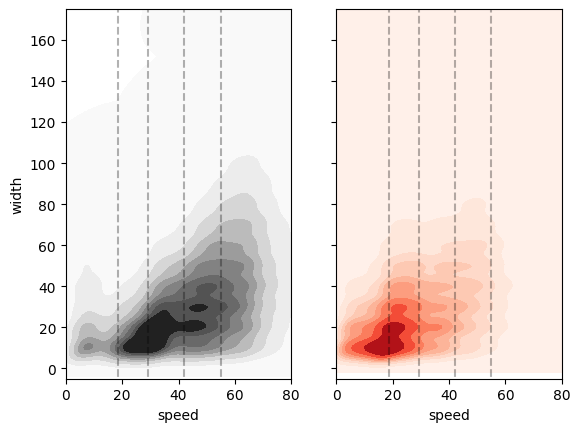

In [4]:
fig, ax = plt.subplots(1,2, sharex=True, sharey=True)

sns.kdeplot(
    data = df.loc[df['cre']=='ctrl',:],
    x = 'speed',
    y='width',
    ax=ax[0],
    cmap='Greys',
    fill=True,
    levels=10,
    thresh=0
)

sns.kdeplot(
    data = df.loc[df['cre']=='ko',:],
    x = 'speed',
    y='width',
    ax=ax[1],
    cmap='Reds',
    fill=True,
    levels=10,
    thresh=0
)

n_bins = 5
speed = df['speed']._values
speed_bins = np.quantile(speed[~np.isnan(speed)],np.linspace(0,1,num=n_bins+1))



for a in ax:
    a.set_xlim([0,80])
    a.set_ylim([-5,175])
    a.vlines(speed_bins[1:-1],-20,180,linestyle='--', color='k',alpha=.3)
# add bins to plots

# for each quantile 

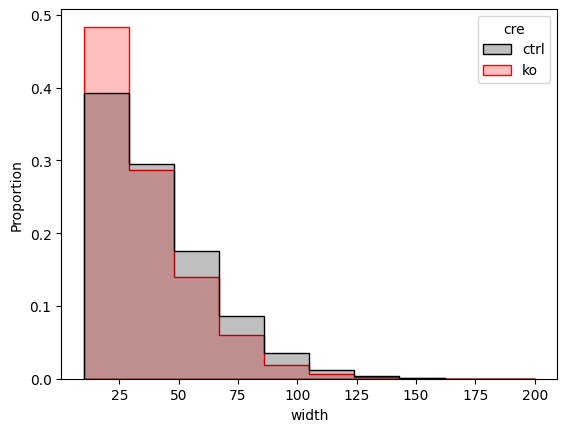

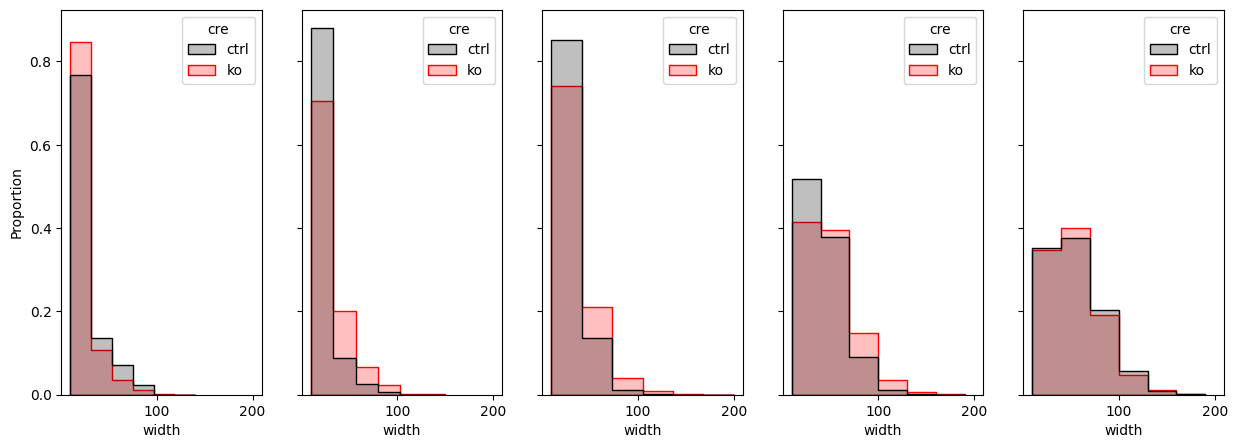

In [10]:
sns.histplot(data=df, 
                x='width', 
                hue='cre', 
                cumulative=False, 
                hue_order=('ctrl', 'ko'),
                palette=['black', 'red'],
                fill=True, element = 'step', stat='proportion', common_norm=False, bins=10)


fig, ax = plt.subplots(1,5, figsize=[15,5],sharex=True, sharey=True)
ranksum = 0
for i, (ledge, redge) in enumerate(zip(speed_bins[:-1], speed_bins[1:])):

    speed_mask = (df['speed']>ledge) * (df['speed']<=redge)
    
    sns.histplot(data=df.loc[speed_mask,:], 
                x='width', 
                hue='cre', 
                cumulative=False, 
                hue_order=('ctrl', 'ko'),
                palette=['black', 'red'],
                fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax[i], bins=6)

    df_speed = df.loc[speed_mask,:]
    r, p = sp.stats.ranksums(df_speed.loc[df_speed['cre']=='ctrl','width'], df_speed.loc[df_speed['cre']=='ko','width'])
    ranksum += r

In [6]:
rank_sum_shuffle = []
rng = np.random.default_rng()
all_mice = ctrl_mice+ko_mice


for i, p in enumerate(itertools.combinations(ctrl_mice+ko_mice, len(ctrl_mice))):
    df_shuff = df.copy()
    df_shuff['cre']='ko'
    regexp = '|'.join(p)
    mask = df_shuff['mouse'].str.contains(regexp)
    df_shuff.loc[mask,'cre']='ctrl'

    _ranksum = 0
    for j, (ledge, redge) in enumerate(zip(speed_bins[:-1], speed_bins[1:])):
        speed_mask = (df_shuff['speed']>ledge) * (df_shuff['speed']<=redge)
        df_speed = df_shuff.loc[speed_mask,:]
        r, p = sp.stats.ranksums(df_speed.loc[df_speed['cre']=='ctrl','width'], df_speed.loc[df_speed['cre']=='ko','width'])
        _ranksum += r
    rank_sum_shuffle.append(_ranksum)
    if i%1000==0:
        print(i)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400


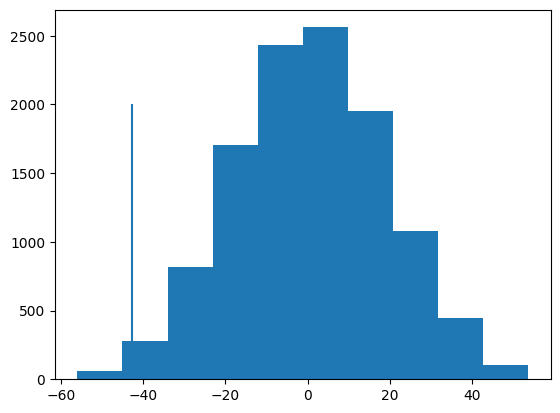

In [8]:
fig, ax = plt.subplots()
ax.hist(rank_sum_shuffle)
ax.vlines(ranksum,0,2000)

In [9]:
p = (rank_sum_shuffle<ranksum).sum().astype(float)/len(rank_sum_shuffle)
print(f'p-value = {p}')

p-value = 0.00743006993006993
